In [18]:
import pandas as pd
import numpy as np


dataset = pd.read_csv('data/flats_final.csv')

In [19]:
dataset.sample(frac = 1)

,floor,floors_count,rooms_count,total_meters,price,distance_to_subway,distance_to_center,district_rank
4700,5,9,1,24.80,10788793,0.000286,3777.487194,3
3523,2,16,4,116.00,29995000,0.001173,10505.164769,7
2011,6,9,3,64.00,8200000,0.000238,12350.387734,13
46,22,27,1,33.77,7799904,0.000000,16176.821459,6
4425,18,26,1,28.10,5620000,0.000507,14765.691187,18
...,...,...,...,...,...,...,...,...
4325,5,5,1,24.18,4650116,0.000000,20640.005498,7
3353,2,5,4,100.00,19000000,0.001635,3133.439214,2
3163,9,9,4,79.80,12300000,0.000967,11636.051784,14
2502,2,6,3,87.73,29439170,0.000000,29304.356602,5


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

In [21]:
import numpy as np
import pandas as pd
import scipy.stats as stats

# Создаем кадр данных pandas с тремя столбцами 'A', 'B', 'C'
# np.random.seed(10)
data = dataset

# Определяем выбросы с использованием метода Z-оценки
z = np.abs(stats.zscore(data))
data_clean_z = data[(z < 3).all(axis=1)]

# Определяем выбросы с использованием межквартильного размаха
Q1 = data.quantile(q=0.25)
Q3 = data.quantile(q=0.75)
IQR = data.apply(stats.iqr)
data_clean_iqr = data[~((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))).any(axis=1)]

# Выводим количество оставшихся строк в кадре данных
print("Количество строк после удаления выбросов (метод Z-оценки):", data_clean_z.shape[0])
print("Количество строк после удаления выбросов (метод межквартильного размаха):", data_clean_iqr.shape[0])

dataset = data_clean_iqr

Количество строк после удаления выбросов (метод Z-оценки): 4622
Количество строк после удаления выбросов (метод межквартильного размаха): 4029


In [26]:
y = dataset['price']
X = dataset.drop(['price'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


X_train_scaled.shape



(3223, 7)

In [27]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

LinearRegression()

In [31]:
y_pred = lin_reg.predict(X_test_scaled)
print(mean_absolute_percentage_error(y_test, y_pred))


deviation = np.abs(y_test - y_pred)

# проверяем, сколько предсказаний отклоняется более чем на 500000
deviation_above_threshold = deviation[deviation > 500000]

# выводим количество предсказаний, которые отклоняются более чем на 500000
print(f"Number of predictions that deviate more than 500000: {len(deviation_above_threshold)}")
print(len(y_test) - len(deviation_above_threshold))

0.25248900994634343
Number of predictions that deviate more than 500000: 711
95


In [32]:
dec_tree = DecisionTreeRegressor(max_depth=20)

dec_tree.fit(X_train, y_train)


DecisionTreeRegressor(max_depth=20)

In [35]:
y_pred = dec_tree.predict(X_test)
print(mean_absolute_percentage_error(y_test, y_pred))
deviation = np.abs(y_test - y_pred)

# проверяем, сколько предсказаний отклоняется более чем на 500000
deviation_above_threshold = deviation[deviation > 500000]

# выводим количество предсказаний, которые отклоняются более чем на 500000
print(f"Number of predictions that deviate more than 500000: {len(deviation_above_threshold)}")
print(len(y_test) - len(deviation_above_threshold))

0.1818377157335665
Number of predictions that deviate more than 500000: 539
267


In [37]:
rand_for = RandomForestRegressor(max_depth=30)
rand_for.fit(X_train, y_train)

RandomForestRegressor(max_depth=30)

In [38]:
y_pred = rand_for.predict(X_test)
print(mean_absolute_percentage_error(y_test, y_pred))

deviation = np.abs(y_test - y_pred)

# проверяем, сколько предсказаний отклоняется более чем на 500000
deviation_above_threshold = deviation[deviation > 500000]

# выводим количество предсказаний, которые отклоняются более чем на 500000
print(f"Number of predictions that deviate more than 500000: {len(deviation_above_threshold)}")
print(len(y_test) - len(deviation_above_threshold))

0.13615108391068853
Number of predictions that deviate more than 500000: 518
288


У линейной регрессии есть отрицательные предсказания, у деревьев и рандомного леса нет!!!

In [109]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd


# конвертируем данные в тензоры PyTorch
X_train_t = torch.FloatTensor(X_train_scaled)
X_test_t = torch.FloatTensor(X_test_scaled)
y_train_t = torch.FloatTensor(y_train.to_numpy())
y_test_t = torch.FloatTensor(y_test.to_numpy())

# создаем DataLoader'ы для обучения и тестирования
train_data = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_data, batch_size=1)
test_data = TensorDataset(X_test_t, y_test_t)
test_loader = DataLoader(test_data, batch_size=1)

In [110]:
# определяем модель

class Net(nn.Module):
    def __init__(self, input_size):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(7, 30)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(30, 120)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(120, 10)
        self.relu3 = nn.ReLU()
        self.fc4 = nn.Linear(10, 1)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu1(out)
        out = self.fc2(out)
        out = self.relu2(out)
        out = self.fc3(out)
        out = self.relu3(out)
        out = self.fc4(out)
        return out

In [114]:
model = Net(7)

# определяем функцию потерь и оптимизатор
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.05)

# обучаем модель
for epoch in range(20):
    total_loss = 0
    for inputs, targets in train_loader:
        # обнуляем градиенты
        optimizer.zero_grad()
        # прямой проход
        outputs = model(inputs)
        # вычисляем потери
        loss = criterion(outputs, targets)
        loss = torch.sqrt(loss)
        total_loss += loss.item()
        # обратный проход
        loss.backward()
        # обновляем веса
        optimizer.step()
    if epoch % 1 == 0:
        print(f'Epoch {epoch+1}, Loss: {total_loss / len(train_loader)}')

# оцениваем модель
model.eval()
with torch.no_grad():
    total_loss = 0
    outputs_l = []
    for inputs, targets in test_loader:
        outputs = model(inputs)
        total_loss += 1 if abs(outputs - targets) <= 500000 else 0
        outputs_l.append(outputs.view(1, ))
    print(mean_absolute_percentage_error(y_test, outputs_l))
    print(f'Average loss: {total_loss}')

d:\projects\flat_price_estimator\venv\Lib\site-packages\torch\nn\modules\loss.py:535: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 1, Loss: 3863988.4228979214
Epoch 2, Loss: 3396958.0197021407
Epoch 3, Loss: 3350955.2380546075
Epoch 4, Loss: 3242196.716374496
Epoch 5, Loss: 3142509.42910332
Epoch 6, Loss: 3021156.7967731925
Epoch 7, Loss: 2929108.8622401487
Epoch 8, Loss: 2849740.3458346264
Epoch 9, Loss: 2785534.6699891407
Epoch 10, Loss: 2767485.6348510706
Epoch 11, Loss: 2702277.5996742165
Epoch 12, Loss: 2665510.4477970833
Epoch 13, Loss: 2643708.70283897
Epoch 14, Loss: 2624281.0067095873
Epoch 15, Loss: 2606523.750892026
Epoch 16, Loss: 2582383.9688178715
Epoch 17, Loss: 2566937.105608129
Epoch 18, Loss: 2579090.104560968
Epoch 19, Loss: 2564143.073611542
Epoch 20, Loss: 2541002.6004498913
0.17404609222639414
Average loss: 163


In [44]:
# y_pred = model(X_test_t)


# print(mean_absolute_percentage_error(y_test, y_pred))


RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

170 с фциями активации


In [44]:
model.eval()
with torch.no_grad():
    total_loss = 0
    for inputs, targets in test_loader:
        outputs = model(inputs)
        total_loss += 1 if abs(outputs - targets) <= 10000000 else 0
    print(f'Average loss: {total_loss}')

Average loss: 899


In [120]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(n_estimators=10000)
gb.fit(X_train, y_train)

y_pred = gb.predict(X_test)
print(mean_absolute_percentage_error(y_test, y_pred))


0.1443496378611783


In [128]:
from lightgbm import LGBMRegressor


reg = LGBMRegressor(n_estimators=10000)
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)
print(mean_absolute_percentage_error(y_test, y_pred))



[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000135 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 836
[LightGBM] [Info] Number of data points in the train set: 3223, number of used features: 7
[LightGBM] [Info] Start training from score 14290945.216258
0.12775548510498355


In [130]:
from xgboost import XGBRegressor

xreg = XGBRegressor(n_estimators=10000, loss='MAE')
xreg.fit(X_train_scaled, y_train)
y_pred = xreg.predict(X_test_scaled)
print(mean_absolute_percentage_error(y_test, y_pred))

0.13154407178624522


In [52]:
from sklearn.svm import SVR

In [56]:
svr = SVR()

svr.fit(X_train_scaled, y_train)

SVR()

In [57]:
y_pred = svr.predict(X_test_scaled)

from sklearn.metrics import mean_absolute_percentage_error
 
print(mean_absolute_percentage_error(y_test, y_pred))

0.504786890783829


In [48]:
y_pred = rand_for.predict(X_test)

print(mean_absolute_percentage_error(y_test, y_pred))

0.20059246788912535


In [49]:
deviation = np.abs(y_test - y_pred)

# проверяем, сколько предсказаний отклоняется более чем на 500000
deviation_above_threshold = deviation[deviation > 500000]

# выводим количество предсказаний, которые отклоняются более чем на 500000
print(f"Number of predictions that deviate more than 500000: {len(deviation_above_threshold)}")
print(len(y_test) - len(deviation_above_threshold))

Number of predictions that deviate more than 500000: 690
314


In [70]:
from catboost import CatBoostRegressor
 
# Initialize the CatBoostRegressor with RMSE as the loss function
model_cb = CatBoostRegressor(loss_function='MAE', learning_rate=0.1, iterations=3000)
 
# Fit the model on the training data with verbose logging every 100 iterations
model_cb.fit(X_train, y_train, verbose=100)

0:	learn: 6420294.0218559	total: 1.88ms	remaining: 5.64s
100:	learn: 1880504.0236507	total: 160ms	remaining: 4.58s
200:	learn: 1578750.5980314	total: 317ms	remaining: 4.41s
300:	learn: 1420781.7677238	total: 469ms	remaining: 4.21s
400:	learn: 1311045.9944238	total: 628ms	remaining: 4.07s
500:	learn: 1227688.5991293	total: 788ms	remaining: 3.93s
600:	learn: 1156533.6033773	total: 947ms	remaining: 3.78s
700:	learn: 1104983.4284497	total: 1.1s	remaining: 3.62s
800:	learn: 1062535.9476255	total: 1.26s	remaining: 3.46s
900:	learn: 1026123.8376851	total: 1.41s	remaining: 3.29s
1000:	learn: 989655.6014414	total: 1.57s	remaining: 3.13s
1100:	learn: 960131.4207954	total: 1.72s	remaining: 2.97s
1200:	learn: 936194.3520279	total: 1.91s	remaining: 2.87s
1300:	learn: 912883.2312633	total: 2.07s	remaining: 2.7s
1400:	learn: 892050.2865740	total: 2.22s	remaining: 2.54s
1500:	learn: 872072.5572483	total: 2.38s	remaining: 2.37s
1600:	learn: 858646.7250274	total: 2.53s	remaining: 2.21s
1700:	learn: 8424

In [71]:
y_pred = model_cb.predict(X_test)

print(mean_absolute_percentage_error(y_test, y_pred))

0.11809169309531677


In [55]:
deviation = np.abs(y_test - y_pred)

# проверяем, сколько предсказаний отклоняется более чем на 500000
deviation_above_threshold = deviation[deviation > 500000]

# выводим количество предсказаний, которые отклоняются более чем на 500000
print(f"Number of predictions that deviate more than 500000: {len(deviation_above_threshold)}")
print(len(y_test) - len(deviation_above_threshold))

Number of predictions that deviate more than 500000: 677
327


<Axes: >

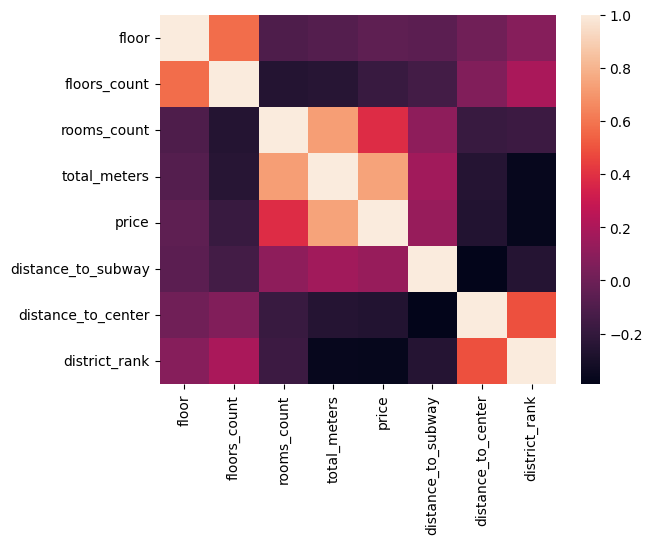

In [57]:
import seaborn as sns
corr = dataset.corr()
sns.heatmap(corr,
            xticklabels=corr.columns.values,
            yticklabels=corr.columns.values)

In [58]:
import numpy as np
import pandas as pd
import scipy.stats as stats

# Создаем кадр данных pandas с тремя столбцами 'A', 'B', 'C'
# np.random.seed(10)
data = dataset

# Определяем выбросы с использованием метода Z-оценки
z = np.abs(stats.zscore(data))
data_clean_z = data[(z < 3).all(axis=1)]

# Определяем выбросы с использованием межквартильного размаха
Q1 = data.quantile(q=0.25)
Q3 = data.quantile(q=0.75)
IQR = data.apply(stats.iqr)
data_clean_iqr = data[~((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))).any(axis=1)]

# Выводим количество оставшихся строк в кадре данных
print("Количество строк после удаления выбросов (метод Z-оценки):", data_clean_z.shape[0])
print("Количество строк после удаления выбросов (метод межквартильного размаха):", data_clean_iqr.shape[0])


Количество строк после удаления выбросов (метод Z-оценки): 4622
Количество строк после удаления выбросов (метод межквартильного размаха): 4029


In [83]:
data_clean_iqr['luxury'] = ((data_clean_iqr['total_meters'] > data_clean_iqr['total_meters'].quantile(0.75)) &
                (data_clean_iqr['distance_to_center'] < data_clean_iqr['distance_to_center'].quantile(0.25)) &
                (data_clean_iqr['district_rank'] < 4)).astype(int)

C:\Users\пк\AppData\Local\Temp\ipykernel_5852\1516849388.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_clean_iqr['luxury'] = ((data_clean_iqr['total_meters'] > data_clean_iqr['total_meters'].quantile(0.75)) &


In [121]:
from catboost import CatBoostRegressor
 

# Создаем кадр данных pandas с тремя столбцами 'A', 'B', 'C'
# np.random.seed(10)


data = dataset

# Определяем выбросы с использованием метода Z-оценки
z = np.abs(stats.zscore(data))
data_clean_z = data[(z < 3).all(axis=1)]

# Определяем выбросы с использованием межквартильного размаха
Q1 = data.quantile(q=0.25)
Q3 = data.quantile(q=0.75)
IQR = data.apply(stats.iqr)
data_clean_iqr = data[~((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))).any(axis=1)]

# Выводим количество оставшихся строк в кадре данных
print("Количество строк после удаления выбросов (метод Z-оценки):", data_clean_z.shape[0])
print("Количество строк после удаления выбросов (метод межквартильного размаха):", data_clean_iqr.shape[0])



y = data_clean_iqr['price']
X = data_clean_iqr.drop(['price'], axis=1)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)



 
# Initialize the CatBoostRegressor with RMSE as the loss function
model_cb = CatBoostRegressor(loss_function='RMSE', learning_rate=0.09, iterations=5000)
 
# Fit the model on the training data with verbose logging every 100 iterations
model_cb.fit(X_train, y_train, verbose=100)



Количество строк после удаления выбросов (метод Z-оценки): 4223
Количество строк после удаления выбросов (метод межквартильного размаха): 3785
0:	learn: 7942661.8769958	total: 1.93ms	remaining: 9.64s
100:	learn: 2809682.5556286	total: 147ms	remaining: 7.14s
200:	learn: 2285142.0328730	total: 291ms	remaining: 6.94s
300:	learn: 1977449.7025120	total: 443ms	remaining: 6.92s
400:	learn: 1764114.6935563	total: 597ms	remaining: 6.84s
500:	learn: 1582187.9141649	total: 750ms	remaining: 6.73s
600:	learn: 1431772.8663324	total: 895ms	remaining: 6.55s
700:	learn: 1309934.7315668	total: 1.04s	remaining: 6.39s
800:	learn: 1218243.7731668	total: 1.19s	remaining: 6.22s
900:	learn: 1131629.2216605	total: 1.33s	remaining: 6.06s
1000:	learn: 1054787.1710732	total: 1.48s	remaining: 5.92s
1100:	learn: 990010.3064501	total: 1.63s	remaining: 5.77s
1200:	learn: 934772.0973649	total: 1.77s	remaining: 5.61s
1300:	learn: 885220.0646372	total: 1.93s	remaining: 5.48s
1400:	learn: 834534.0817439	total: 2.07s	rema

In [122]:
data_clean_iqr['luxury'].mean()

0.0

In [123]:
y_pred = model_cb.predict(X_test)

print(mean_absolute_percentage_error(y_test, y_pred))

0.12965708089373518


In [124]:
feature_importance = model_cb.get_feature_importance()

# Выводим результат
for feature, importance in zip(X_train.columns, feature_importance):
    print(f"Feature '{feature}': Importance = {importance:.4f}")

Feature 'floor': Importance = 3.7124
Feature 'floors_count': Importance = 9.7448
Feature 'rooms_count': Importance = 11.1080
Feature 'total_meters': Importance = 41.1791
Feature 'distance_to_subway': Importance = 7.6553
Feature 'distance_to_center': Importance = 16.1227
Feature 'district_rank': Importance = 10.4776
Feature 'luxury': Importance = 0.0000


<Axes: >

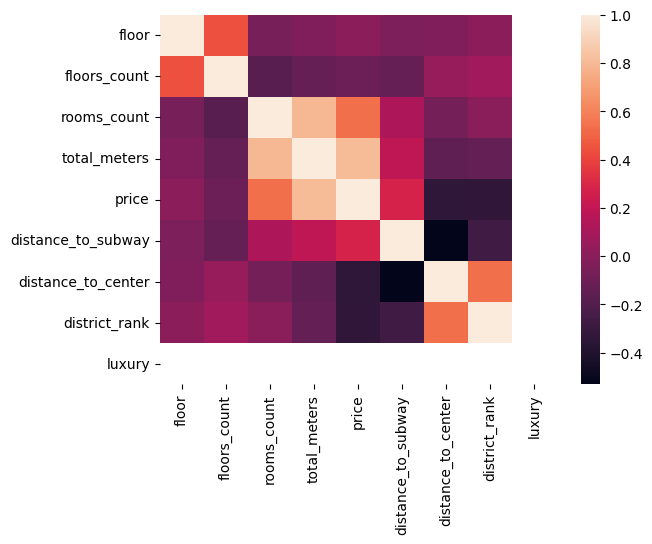

In [125]:
import seaborn as sns
corr = data_clean_iqr.corr()
sns.heatmap(corr,
            xticklabels=corr.columns.values,
            yticklabels=corr.columns.values)